In [1]:

import os
from pathlib import Path
from acados_template import AcadosOcp
from commom_utils.ode_system import ODESystem, check_system_ok, MHESyntheticDataGenerator
import numpy as np
import matplotlib.pyplot as plt

from gauss_newton.gauss_newton_math import SystemJacobian

from commom_utils.systems import *
from mhe.mhe_base_model_interface import MheModel, MheCogeGenerator
from mhe.params import MheParams
from mhe.mhe_utils import MheEstimationData, run_mhe_estimation, plot_mhe_results

In [ ]:
import numpy as np
from mhe.params import MheParams

# Общие параметры
mhe_horizont = 300
ts = 0.02

# Словарь конфигураций
configs = {
    "MassSpringDamper": {
        "system_class": MassSpringDamper,
        "system_args": [],  # аргументы конструктора (если есть)
        "c0": np.array([1.0, 10.0]),
        "theta_true": np.array([3, 1.0]),
        "theta_init_factor": 0.0,  # множитель для theta_true (0 = нулевая инициализация)
        "measurements_residual_r": np.diag([1, 1]),
        "state_prior_q0": np.diag([1, 1]),
        "noise_peanlty_w": np.eye(2) * 1e3,
        "fim_scaler": 0.2,
        "bounds_noise": [[-0.01, 0.01]] * 2,
        "bounds_state": [[-np.inf, np.inf]] * 2,
        "bounds_param": [[-2000, 2000]] * 2,
    },
    "KinematicBycicle": {
        "system_class": KinematicBycicle,
        "system_args": [2.65],  # wheelbase
        "c0": np.array([0]),
        "theta_true": np.array([0.05, np.deg2rad(-0.3)]),
        "theta_init_factor": 0.0,
        "measurements_residual_r": np.diag([1]),
        "state_prior_q0": np.diag([1]),
        "noise_peanlty_w": np.eye(1) * 1e3,
        "fim_scaler": 0.2,
        "bounds_noise": [[-0.01, 0.01]],
        "bounds_state": [[-np.inf, np.inf]],
        "bounds_param": [np.deg2rad([-5, 5]), [-1, 1]],
    },
    "Integrator": {
        "system_class": Integrator,
        "system_args": [],
        "c0": np.array([0.0, 0.0]),
        "theta_true": np.array([1.0]),
        "theta_init_factor": 0.0,
        "measurements_residual_r": np.diag([1]),
        "state_prior_q0": np.diag([1, 1]),
        "noise_peanlty_w": np.eye(2) * 1e3,
        "fim_scaler": 0.2,
        "bounds_noise": [[-0.01, 0.01]] * 2,
        "bounds_state": [[-1e5, 1e5]] * 2,
        "bounds_param": [[0, 20]],
    },
    "DelaySystem": {
        "system_class": DelaySystem,
        "system_args": [1],  # порядок (1 = Паде 1‑го порядка)
        "c0": np.array([0.0]),  # начальное состояние для одного состояния
        "theta_true": np.array([0.5]),
        "theta_init_factor": 0.0,
        "measurements_residual_r": np.diag([1]),
        "state_prior_q0": np.diag([1]),
        "noise_peanlty_w": np.eye(1) * 1e3,
        "fim_scaler": 0.2,
        "bounds_noise": [[-0.01, 0.01]],
        "bounds_state": [[-1e5, 1e5]],
        "bounds_param": [[0, 20]],
    }
}

# Выбор модели (измените ключ)
model_key = "DelaySystem"   # например, "MassSpringDamper", "KinematicBycicle", "Integrator"
cfg = configs[model_key]

# Создаём систему
system = cfg["system_class"](*cfg["system_args"])

# Начальное состояние (c0)
c0 = cfg["c0"]

# Истинные параметры и начальная оценка
theta_true = cfg["theta_true"]
if cfg["theta_init_factor"] == 0.0:
    theta_init = np.zeros_like(theta_true)
else:
    theta_init = theta_true * cfg["theta_init_factor"] + (np.random.rand(len(theta_true)) - 0.5) * 0.05

# Параметры MHE
mhe_params = MheParams(
    dt=ts,
    mhe_horizont=mhe_horizont,
    state_prior_q0=cfg["state_prior_q0"],
    noise_peanlty_w=cfg["noise_peanlty_w"],
    measurements_residual_r=cfg["measurements_residual_r"],
    bounds_noise=cfg["bounds_noise"],
    bounds_state=cfg["bounds_state"],
    bounds_param=cfg["bounds_param"],
    fim_scaler=cfg["fim_scaler"]
)

mhe_params.print()

In [3]:
mhe_horizont = 300
ts = 0.02


if(0):
    measurements_residual_r = np.diag([1, 1])                 # R: 1x1
    state_prior_q0 = np.diag([1, 1])                          # Q0: 1x1
    noise_peanlty_w = np.eye(2) * 1e3                    # Q: 1x1
    fim_scaler = 0.2

    mhe_params = MheParams(
            dt=ts,
            mhe_horizont=mhe_horizont,
            state_prior_q0=state_prior_q0,
            noise_peanlty_w=noise_peanlty_w,
            measurements_residual_r=measurements_residual_r,
            bounds_noise = 2*[np.array([-0.01, 0.01])],
            bounds_state = 2*[np.array([-np.inf, np.inf])],
            bounds_param = 2*[np.array([-2000, 2000])],
            fim_scaler=fim_scaler
        )

    mhe_params.print()

    system =  MassSpringDamper()
    c0 = np.array([1.0, 10.0]) 
    theta_true = np.array([3, 1.0])
  
elif(0):
    measurements_residual_r = np.diag([1])                 # R: 1x1
    state_prior_q0 = np.diag([1])                          # Q0: 1x1
    noise_peanlty_w = np.eye(1) * 1e3                    # Q: 1x1
    fim_scaler = 0.2
    wheel_base = 2.65

    mhe_params = MheParams(
            dt=ts,
            mhe_horizont=mhe_horizont,
            state_prior_q0=state_prior_q0,
            noise_peanlty_w=noise_peanlty_w,
            measurements_residual_r= measurements_residual_r,
            bounds_noise = [[-0.01, 0.01]],
            bounds_state = [[-np.inf, np.inf]],
            bounds_param = [np.deg2rad([-5, 5]), [-1, 1]],
            fim_scaler=fim_scaler
        )

    mhe_params.print()

    system =  KinematicBycicle(wheelbase = 2.65)
    c0 = np.array([0]) 
    theta_true = np.array([0.05, np.deg2rad(-0.3)])

elif(0):
    measurements_residual_r = np.diag([1])                 # R: 1x1
    state_prior_q0 = np.diag([1, 1])                           # Q0: 1x1
    noise_peanlty_w = np.eye(2) * 1e3                    # Q: 1x1
    fim_scaler = 0.2

    mhe_params = MheParams(
            dt=ts,
            mhe_horizont=mhe_horizont,
            state_prior_q0=state_prior_q0,
            noise_peanlty_w=noise_peanlty_w,
            measurements_residual_r=measurements_residual_r,
            bounds_noise = 2*[[-0.01, 0.01]],
            bounds_state = 2*[[-1e5, 1e5]],
            bounds_param = [[0, 20]],
            fim_scaler=fim_scaler
        )

    mhe_params.print()

    system =  Integrator()
    c0 =  np.array([0.0, 0.0])
    theta_true = np.array([1.0])

elif(1):
    N = 1
    measurements_residual_r = np.diag([1])                 # R: 1x1
    state_prior_q0 = np.diag(N*[1])                           # Q0: 1x1
    noise_peanlty_w = np.eye(N) * 1e3                    # Q: 1x1
    fim_scaler = 0.2

    mhe_params = MheParams(
            dt=ts,
            mhe_horizont=mhe_horizont,
            state_prior_q0=state_prior_q0,
            noise_peanlty_w=noise_peanlty_w,
            measurements_residual_r=measurements_residual_r,
            bounds_noise = N*[[-0.01, 0.01]],
            bounds_state = N*[[-1e5, 1e5]],
            bounds_param = [[0, 20]],
            fim_scaler=fim_scaler
        )

    mhe_params.print()

    system =  DelaySystem(N)
    c0 =  np.array(N*[0.0])
    theta_true = np.array([0.5])
    
class MyCogeGenerator(MheCogeGenerator):
    def __init__(self):
        super().__init__(system, mhe_params,  Path(os.getcwd())/'mhe/tmp_generated', 'kinematik_mhe')

    def modify_ocp_problem(self, ocp_mhe: AcadosOcp) -> AcadosOcp:
        ocp_mhe.solver_options.print_level = 2
        ocp_mhe.solver_options.nlp_solver_stats_level = 2
        ocp_mhe.solver_options.nlp_solver_max_iter =120
        #ocp_mhe.solver_options.nlp_solver_tol_stat = 1e-3
        ocp_mhe.solver_options.nlp_solver_type = 'SQP'
        ocp_mhe.solver_options.nlp_solver_max_iter = 200
        ocp_mhe.solver_options.nlp_solver_tol_stat = 1e-4
        ocp_mhe.solver_options.nlp_solver_tol_eq = 1e-4
        ocp_mhe.solver_options.nlp_solver_tol_ineq = 1e-4
        ocp_mhe.solver_options.nlp_solver_tol_comp = 1e-4
        ocp_mhe.solver_options.hessian_approx = 'GAUSS_NEWTON'
        ocp_mhe.solver_options.globalization = 'FIXED_STEP'
        ocp_mhe.solver_options.globalization_fixed_step_length = 0.9
        ocp_mhe.solver_options.levenberg_marquardt = 1e-6
        ocp_mhe.solver_options.qp_solver = 'PARTIAL_CONDENSING_HPIPM'
        ocp_mhe.solver_options.hpipm_options = {
            'scale': 1,
            'scale_ux': 1,
            'iter_max': 1000,
            'tol': 1e-6,
            'reg_epsilon': 1e-6,
            'reg_epsilon_s': 1e-6,
        }
        return ocp_mhe

generator = MyCogeGenerator()

assert check_system_ok(system) == True



INFO:2026-04-10 15:12:47,466:jax._src.xla_bridge:752: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
2026-04-10 15:12:47,466 - INFO - Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


dt: 0.02
mhe_horizont: 300
state_prior_q0: [[1]]
noise_peanlty_w: [[1000.]]
measurements_residual_r: [[1]]
bounds_param: [[0, 20]]
bounds_state: [[-100000.0, 100000.0]]
bounds_noise: [[-0.01, 0.01]]
fim_scaler: 0.2


In [18]:
acados_solver_mhe = generator.generate_code()

Please export ACADOS_SOURCE_DIR to avoid this warning.
[-100000.       0.]
[1.e+05 2.e+01]
[0 1]
kinematik_mhe
1 1

got cost_type EXTERNAL for cost_type_0, cost_type, cost_type_e, hessian_approx: 'GAUSS_NEWTON'.
With this setting, acados will proceed computing the exact Hessian for the cost term and no Hessian contribution from constraints and dynamics.
If the external cost is a linear least squares cost, this coincides with the Gauss-Newton Hessian.
Note: There is also the option to use the external cost module with a numerical Hessian approximation (see `ext_cost_num_hess`).
OR the option to provide a symbolic custom Hessian approximation (see `cost_expr_ext_cost_custom_hess`).


got cost_type EXTERNAL for cost_type_0, cost_type, cost_type_e, hessian_approx: 'GAUSS_NEWTON'.
With this setting, acados will proceed computing the exact Hessian for the cost term and no Hessian contribution from constraints and dynamics.
If the external cost is a linear least squares cost, this coincides w

In [19]:
# Create the generator

simulation_system = system# KinematicBycicleActuator(wheelbase=2.65, kp = 200, kv = 10)


data_gen = MHESyntheticDataGenerator(simulation_system, sigma=0.0)

# Parameters
t0 = 0
T_f = mhe_params.dt * mhe_params.mhe_horizont          
N_measurement = mhe_params.mhe_horizont               
overlap_points = 1#int(N_measurement*0.5)
num_windows = 20                                    # number of overlapping windows


# Generate exact windows
t_windows, u_windows, meas_windows, full_windows = data_gen.generate_sliding_windows_exact(
    c0, theta_true, t0, T_f, num_windows, N_measurement, overlap_points=overlap_points
)

# Check the time span of the first window
print(f"Window 0: start={t_windows[0][0]:.6f}, end={t_windows[0][-1]:.6f}, span={t_windows[0][-1]-t_windows[0][0]:.6f}")
# This should equal T_f
def get_window(i):
    return t_windows[i], u_windows[i], meas_windows[i]

Window 0: start=0.000000, end=6.000000, span=6.000000


/tmp/ipykernel_492835/153685526.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


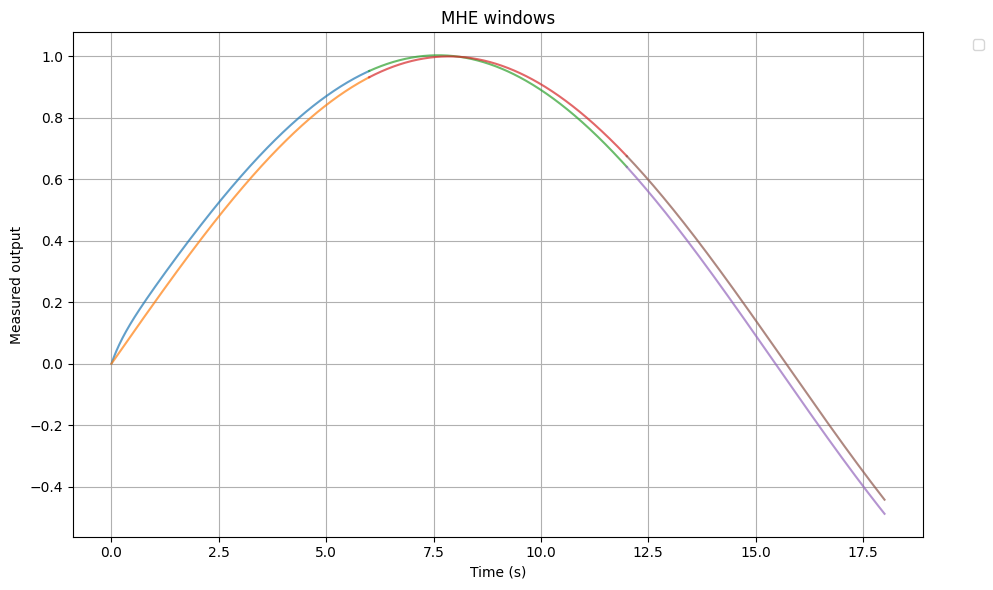

In [21]:
plt.figure(figsize=(10, 6))
for i in range(0, 3):
    t, simU, simY = get_window(i)
    plt.plot(t, simY[:, :3], alpha=0.7)
    plt.plot(t, simU[:, :3], alpha=0.7)

plt.xlabel('Time (s)')
plt.ylabel('Measured output')
plt.title('MHE windows')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

In [22]:
initial_theta = np.array([2.1])#theta_true*0.1


results = run_mhe_estimation(
    mhe_model=generator.get_model(),
    acados_solver_factory= acados_solver_mhe,   # you might pass a pre‑created solver or a factory
    get_window_func=get_window,
    overlap_points=overlap_points,
    initial_theta = initial_theta,
    mhe_params=mhe_params,
    num_windows=10,#num_windows,
    ridge_reg = 1e-5,
    R_inv=mhe_params.measurements_residual_r,
    forgetting_factor = 0.01,
    compute_advanced_fim = True,
    plot=0   # set to True if you want live plots
)

MHE windows:  20%|██        | 2/10 [00:00<00:01,  7.30window/s]

  # it     res_stat       res_eq     res_ineq     res_comp   qp_stat   qp_iter  step_norm    lm_reg.     alpha   
     0   3.6465e-02   1.8635e+00   0.0000e+00   0.0000e+00         0         0   0.00e+00   0.00e+00  9.00e-01    
     1   3.6449e-03   3.6401e-03   0.0000e+00   6.9922e-06         0        10   2.22e+00   1.00e-06  9.00e-01    
     2   3.1705e-03   2.0584e-03   0.0000e+00   3.0745e-05         0         2   1.07e+00   1.00e-06  9.00e-01    
     3   7.5569e-04   4.3607e-04   0.0000e+00   9.3222e-06         0         2   2.69e-01   1.00e-06  9.00e-01    
     4   2.0042e-04   1.4258e-04   0.0000e+00   3.4119e-05         0         2   1.12e-01   1.00e-06  9.00e-01    
     5   4.0219e-05   2.2736e-05   0.0000e+00   6.9506e-06         0         2   2.03e-02   1.00e-06  9.00e-01    
Optimal solution found! Converged to KKT point.
  # it     res_stat       res_eq     res_ineq     res_comp   qp_stat   qp_iter  step_norm    lm_reg.     alpha   
     0   3.6639e-02   5.3456e-02  

MHE windows:  40%|████      | 4/10 [00:00<00:00,  7.38window/s]

  # it     res_stat       res_eq     res_ineq     res_comp   qp_stat   qp_iter  step_norm    lm_reg.     alpha   
     0   4.4298e-02   8.0622e-02   0.0000e+00   5.5152e-05         0         0   0.00e+00   0.00e+00  9.00e-01    
     1   4.4298e-03   7.6642e-03   0.0000e+00   5.6690e-06         0         2   1.11e+00   1.00e-06  9.00e-01    
     2   4.4298e-04   5.2520e-04   0.0000e+00   3.3460e-06         0         2   1.11e-01   1.00e-06  9.00e-01    
     3   4.4298e-05   3.2741e-05   0.0000e+00   4.2972e-06         0         2   2.39e-02   1.00e-06  9.00e-01    
Optimal solution found! Converged to KKT point.
  # it     res_stat       res_eq     res_ineq     res_comp   qp_stat   qp_iter  step_norm    lm_reg.     alpha   
     0   4.5130e-02   8.8351e-02   0.0000e+00   4.2972e-06         0         0   0.00e+00   0.00e+00  9.00e-01    
     1   4.5130e-03   8.7911e-03   0.0000e+00   4.6553e-07         0         2   1.13e+00   1.00e-06  9.00e-01    
     2   4.5126e-04   8.4398e-04  

MHE windows:  60%|██████    | 6/10 [00:00<00:00,  7.21window/s]

  # it     res_stat       res_eq     res_ineq     res_comp   qp_stat   qp_iter  step_norm    lm_reg.     alpha   
     0   2.6833e-02   5.6920e-02   0.0000e+00   5.6107e-07         0         0   0.00e+00   0.00e+00  9.00e-01    
     1   2.6833e-03   5.6719e-03   0.0000e+00   9.3992e-08         0         2   6.74e-01   1.00e-06  9.00e-01    
     2   2.6834e-04   5.4720e-04   0.0000e+00   1.2241e-07         0         2   6.77e-02   1.00e-06  9.00e-01    
     3   2.6834e-05   5.2573e-05   0.0000e+00   2.2480e-07         0         2   6.73e-03   1.00e-06  9.00e-01    
Optimal solution found! Converged to KKT point.
  # it     res_stat       res_eq     res_ineq     res_comp   qp_stat   qp_iter  step_norm    lm_reg.     alpha   
     0   4.5131e-02   9.0602e-02   0.0000e+00   2.2480e-07         0         0   0.00e+00   0.00e+00  9.00e-01    
     1   4.5131e-03   9.0596e-03   0.0000e+00   3.4200e-08         0         2   1.13e+00   1.00e-06  9.00e-01    
     2   4.5132e-04   9.0542e-04  

MHE windows:  80%|████████  | 8/10 [00:01<00:00,  6.77window/s]

  # it     res_stat       res_eq     res_ineq     res_comp   qp_stat   qp_iter  step_norm    lm_reg.     alpha   
     0   4.3531e-02   8.6142e-02   0.0000e+00   1.3638e-08         0         0   0.00e+00   0.00e+00  9.00e-01    
     1   4.3531e-03   8.6215e-03   0.0000e+00   1.5581e-08         0         2   1.09e+00   1.00e-06  9.00e-01    
     2   4.3532e-04   8.6781e-04   0.0000e+00   1.6060e-08         0         2   1.09e-01   1.00e-06  9.00e-01    
     3   4.3534e-05   8.7362e-05   0.0000e+00   6.4008e-07         0         2   1.08e-02   1.00e-06  9.00e-01    
Optimal solution found! Converged to KKT point.
  # it     res_stat       res_eq     res_ineq     res_comp   qp_stat   qp_iter  step_norm    lm_reg.     alpha   
     0   4.0121e-02   8.2409e-02   0.0000e+00   6.4008e-07         0         0   0.00e+00   0.00e+00  9.00e-01    
     1   4.0121e-03   8.2296e-03   0.0000e+00   8.0579e-08         0         2   1.01e+00   1.00e-06  9.00e-01    
     2   4.0122e-04   8.1592e-04  

MHE windows: 100%|██████████| 10/10 [00:01<00:00,  6.75window/s]

  # it     res_stat       res_eq     res_ineq     res_comp   qp_stat   qp_iter  step_norm    lm_reg.     alpha   
     0   4.5131e-02   9.0692e-02   0.0000e+00   3.4030e-08         0         0   0.00e+00   0.00e+00  9.00e-01    
     1   4.5132e-03   9.0737e-03   0.0000e+00   1.6878e-08         0         2   1.13e+00   1.00e-06  9.00e-01    
     2   4.5132e-04   9.1053e-04   0.0000e+00   1.5452e-08         0         2   1.13e-01   1.00e-06  9.00e-01    
     3   4.5132e-05   9.1612e-05   0.0000e+00   1.5302e-08         0         2   1.13e-02   1.00e-06  9.00e-01    
Optimal solution found! Converged to KKT point.
  # it     res_stat       res_eq     res_ineq     res_comp   qp_stat   qp_iter  step_norm    lm_reg.     alpha   
     0   3.3808e-02   6.4766e-02   0.0000e+00   1.5302e-08         0         0   0.00e+00   0.00e+00  9.00e-01    
     1   3.3809e-03   6.4835e-03   0.0000e+00   1.9107e-08         0         2   8.45e-01   1.00e-06  9.00e-01    
     2   3.3809e-04   6.4965e-04  

In [24]:
results[-1].param_est

array([0.47740283])

(2991, 1)
(2991, 1)


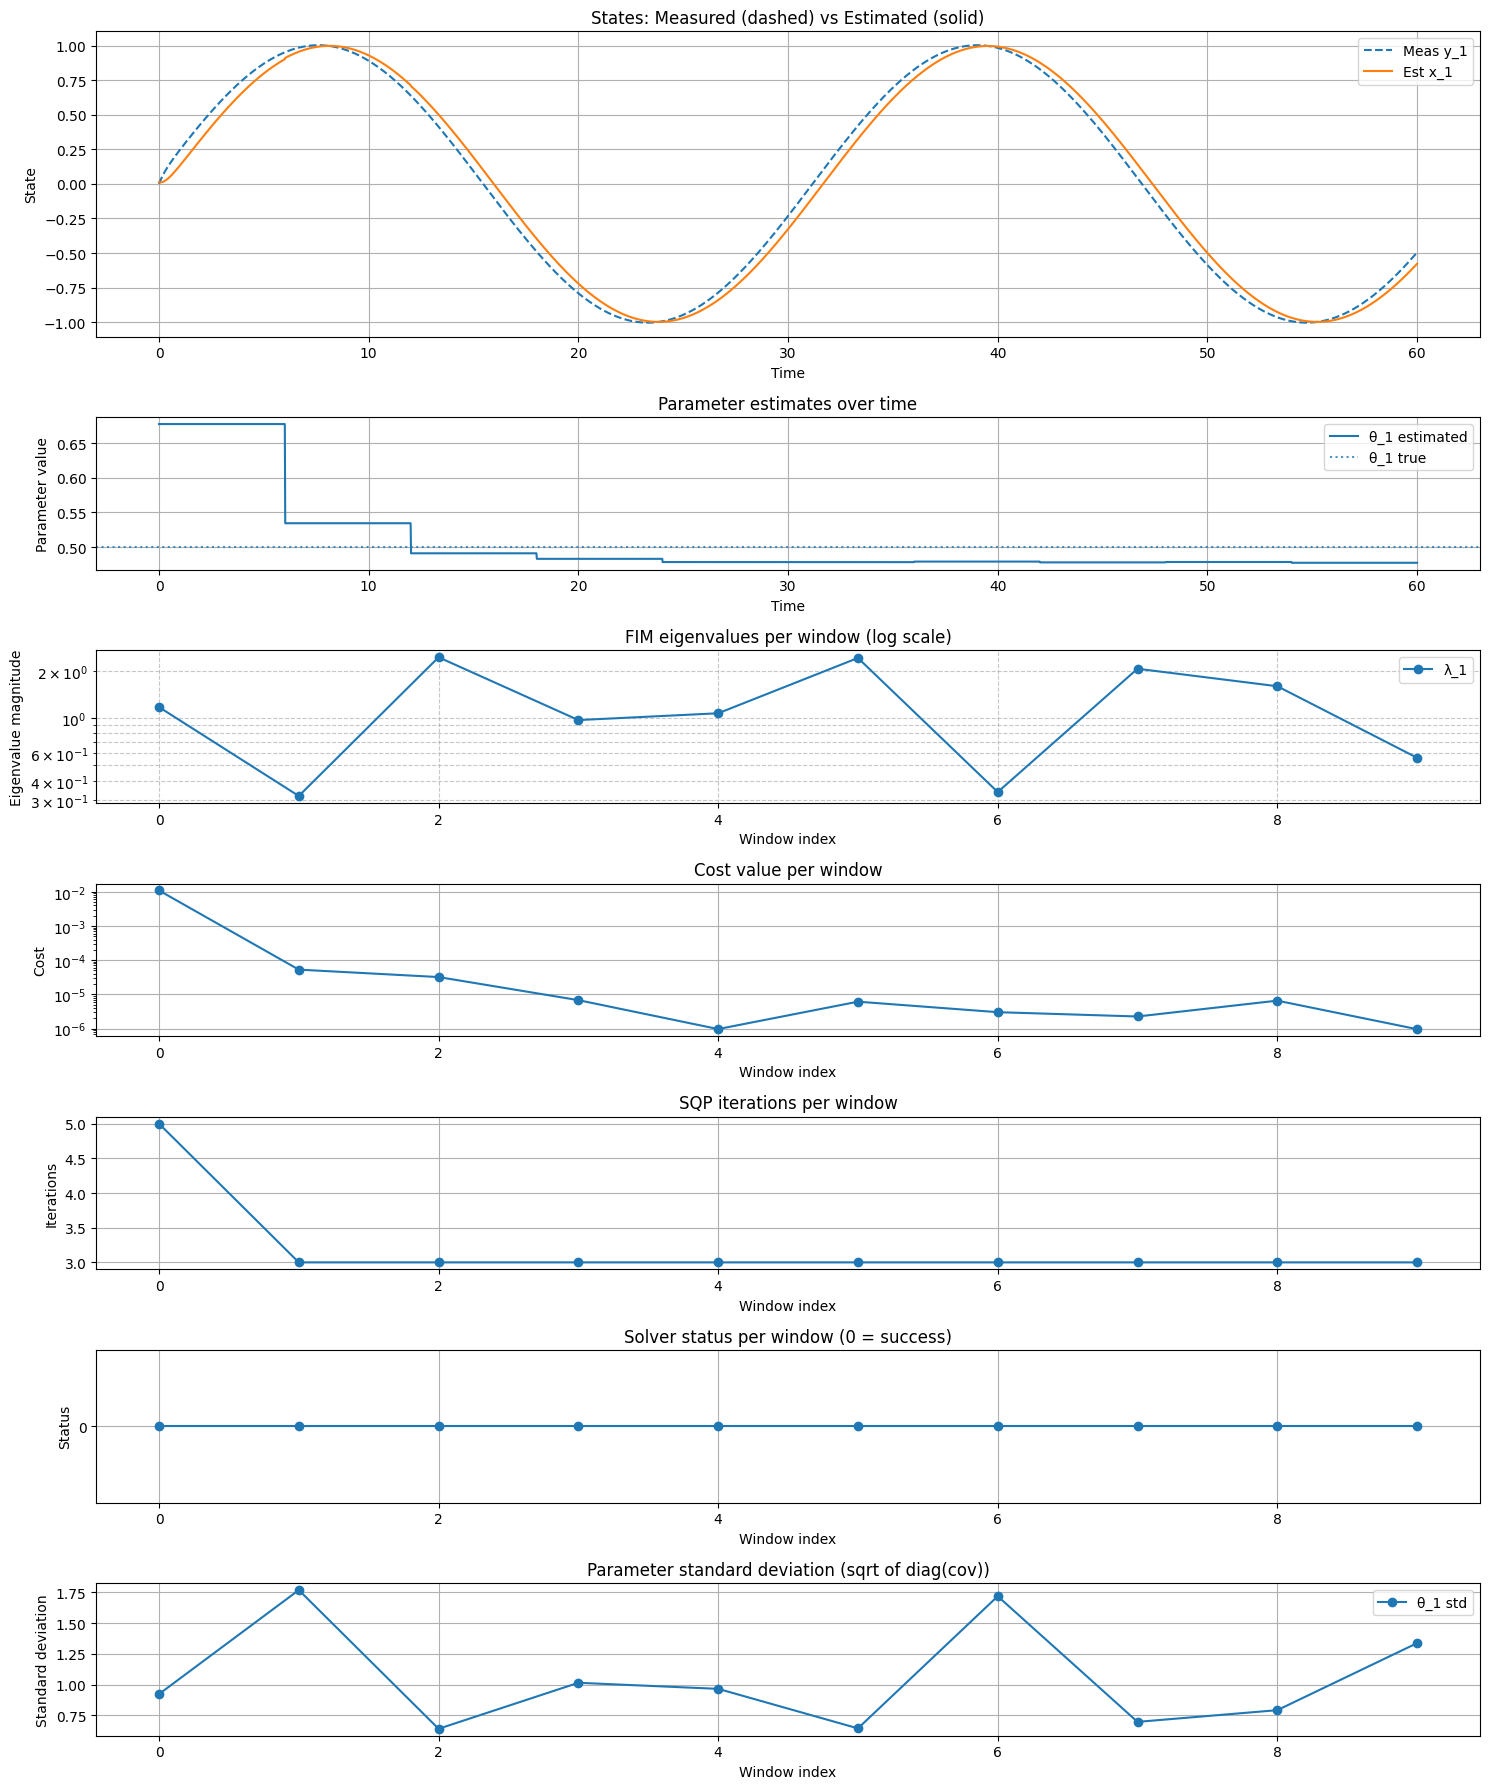

In [23]:
plot_mhe_results(results, overlap=overlap_points,
                 initial_params=None,
                 theta_true=theta_true,   # your true parameter array
                 plot_states=True,
                 plot_params=True,
                 plot_eigvals=True,
                 plot_noise=False,
                 plot_cost=True,
                 plot_iter=True,
                 plot_status=True,
                 figsize=(15, 18))   # slightly larger to accommodate taller first plot

In [33]:
initial_theta = theta_true
t_batch, simU, simY = get_window(11)
unknown_state_length = 0


initial_x0 = np.hstack((simY[0]))
print(initial_x0)
R_inv = np.diag(1*[1])
mhe_model=generator.get_model()
F = mhe_model.compute_fim(simY.shape[0], mhe_params.dt, simU, initial_x0, initial_theta, R_inv)
F
#set_mhe_solver(mhe_model, acados_solver_mhe, simY, simU, initial_x0, initial_theta, mhe_params.dt, N_measurement, unknown_state_length, R_inv)

[0.40193397]


array([[4.03211488]])